In [2]:
import os
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
from torchvision.models import ResNet18_Weights
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


In [3]:
VOC_COLORMAP = [
    [0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
    [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
    [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
    [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
    [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
    [0, 64, 128]
]


VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat',
    'bottle', 'bus', 'car', 'cat', 'chair',
    'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor'
]

def voc_colormap2label():
    """RGB颜色 → 类别索引映射表"""

    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for idx, color in enumerate(VOC_COLORMAP):
        r, g, b = color
        colormap2label[r * 256 * 256 + g * 256 + b] = idx
    return colormap2label

def voc_label_indices(color_img: torch.Tensor, colormap2label: torch.Tensor):
    """
    VOC彩色标签图 → 单通道类别索引图
    :param color_img: Tensor shape [3, H, W] RGB
    :return: shape [H, W] 每个像素0~20类别索引
    """
    # [3,H,W] -> [H,W,3]
    color_img = color_img.permute(1, 2, 0).numpy().astype(np.int32)
    r = color_img[:, :, 0]
    g = color_img[:, :, 1]
    b = color_img[:, :, 2]
    idx = r * 256 * 256 + g * 256 + b
    return colormap2label[idx]

In [4]:
def show_images(imgs, num_rows, num_cols, scale=2):
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < len(imgs):
            # tensor [C,H,W] -> numpy [H,W,C]
            ax.imshow(imgs[i].permute(1, 2, 0))
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [5]:
"""图像增广"""

def voc_rand_crop(feature: torch.Tensor, label: torch.Tensor, crop_h: int, crop_w: int):
    """原图&标签同步随机裁剪"""
    
    rect = torchvision.transforms.RandomCrop.get_params(feature, (crop_h, crop_w))
    feature = TF.crop(feature, *rect)
    label = TF.crop(label, *rect)
    return feature, label


def voc_center_crop(feature: torch.Tensor, label: torch.Tensor, crop_h: int, crop_w: int):
    """原图&标签同步中心裁剪（验证集使用，保证batch内尺寸一致）"""
    
    _, h, w = feature.shape
    top = (h - crop_h) // 2
    left = (w - crop_w) // 2
    rect = (top, left, crop_h, crop_w)
    feature = TF.crop(feature, *rect)
    label = TF.crop(label, *rect)
    return feature, label

In [6]:
class VOCSegDataset(Dataset):
    def __init__(
        self,
        is_train: bool,
        crop_size: tuple[int, int],
        voc_dir: str,
        filter_small: bool = True
    ):
        """
        :param is_train: True训练集 / False验证集
        :param crop_size: (height, width) 随机裁剪尺寸
        :param voc_dir:
        :param filter_small: 是否过滤小于裁剪尺寸的图片
        """

        self.is_train = is_train
        self.crop_h, self.crop_w = crop_size
        self.voc_dir = voc_dir
        self.filter_small = filter_small

        # 路径校验
        assert os.path.exists(voc_dir), f"数据集路径不存在：{voc_dir}"
        split_file = "train.txt" if is_train else "val.txt"
        txt_path = os.path.join(voc_dir, "ImageSets", "Segmentation", split_file)

        # 读取样本名
        with open(txt_path, encoding="utf-8") as f:
            self.all_names = [n.strip() for n in f.read().split()]

        # 颜色映射表（只初始化一次）
        self.colormap2label = voc_colormap2label()

        # 过滤过小图片（提前筛选样本名称，不用加载图片）
        self.valid_names = []
        for name in self.all_names:
            img_path = os.path.join(voc_dir, "JPEGImages", f"{name}.jpg")
            img = torchvision.io.read_image(img_path, torchvision.io.ImageReadMode.RGB)
            _, h, w = img.shape
            if (not filter_small) or (h >= self.crop_h and w >= self.crop_w):
                self.valid_names.append(name)
        print(f"读取完成，有效样本数量：{len(self.valid_names)}")

    def normalize_image(self, img: torch.Tensor) -> torch.Tensor:
        """图像标准化：[0,255] -> ImageNet归一化"""
        img = img.float() / 255.0
        mean = VOC_MEAN.view(3, 1, 1)
        std = VOC_STD.view(3, 1, 1)
        img = (img - mean) / std
        return img

    def __len__(self):
        return len(self.valid_names)

    def __getitem__(self, idx: int):
        """动态加载图片，不在初始化缓存全部图像"""

        name = self.valid_names[idx]
        img_path = os.path.join(self.voc_dir, "JPEGImages", f"{name}.jpg")
        label_path = os.path.join(self.voc_dir, "SegmentationClass", f"{name}.png")

        # 读取原图、彩色标签
        feature = torchvision.io.read_image(img_path, torchvision.io.ImageReadMode.RGB)
        label_rgb = torchvision.io.read_image(label_path, torchvision.io.ImageReadMode.RGB)

        # 训练集：随机裁剪；验证集：中心裁剪到固定尺寸（保证batch内尺寸一致）
        if self.is_train:
            feature, label_rgb = voc_rand_crop(feature, label_rgb, self.crop_h, self.crop_w)
        else:
            feature, label_rgb = voc_center_crop(feature, label_rgb, self.crop_h, self.crop_w)

        # 图像归一化
        feature = self.normalize_image(feature)
        # RGB标签图映射为类别索引
        label = voc_label_indices(label_rgb, self.colormap2label)

        return feature, label


def load_data_voc(
    batch_size: int,
    crop_size: tuple[int, int],
    voc_root: str,
    num_workers: int = 0
) -> tuple[DataLoader, DataLoader]:
    """
    加载Pascal VOC2012 语义分割数据集迭代器
    :param batch_size:批次大小
    :param crop_size: (H,W)随机裁剪尺寸
    :param voc_root: VOCdevkit/VOC2012本地路径
    :param num_workers: 加载线程
    :return: train_iter, test_iter
    """
    
    train_dataset = VOCSegDataset(is_train=True, crop_size=crop_size, voc_dir=voc_root)
    test_dataset = VOCSegDataset(is_train=False, crop_size=crop_size, voc_dir=voc_root)

    train_iter = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=True if num_workers > 0 else False
    )
    test_iter = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=True,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=True if num_workers > 0 else False
    )
    return train_iter, test_iter

**上采样**

下采样可以将数据压缩\
但是如果输入图像和输出图像的空间维度相同，在以像素级分类的语义分割中会很方便

尝试通过转置卷积进行上采样，增加特征图的空间维度

**全卷积网络（FNC）**

先通过卷积把原图变成特征图，再通过上采样把特征图的宽和高转换为原始图像的尺寸

输出的类别预测与输入图像在像素级上具有一一对应的关系：通道维的输出即为该位置对应的像素的类别预测

In [7]:
def bilinear_kernel(in_channels: int, out_channels: int, kernel_size: int) -> torch.Tensor:
    """
    生成双线性插值卷积核，初始化转置卷积
    限制：in_channels == out_channels（逐通道独立上采样）
    """

    factor = (kernel_size + 1) // 2
    center = factor - 1 if (kernel_size % 2 == 1) else factor - 0.5

    y = torch.arange(kernel_size).reshape(-1, 1)
    x = torch.arange(kernel_size).reshape(1, -1)
    filt = (1 - torch.abs(y - center) / factor) * (1 - torch.abs(x - center) / factor)

    weight = torch.zeros((in_channels, out_channels, kernel_size, kernel_size))
    weight[range(in_channels), range(out_channels), :, :] = filt
    return weight


class FCN8s_ResNet18(nn.Module):
    def __init__(self, num_classes: int = 21, freeze_backbone: bool = False):
        super().__init__()
        self.num_classes = num_classes

        # 加载预训练ResNet18
        resnet = torchvision.models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

        # 特征提取层，拆分用于获取多层特征
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1   # 下采样 4
        self.layer2 = resnet.layer2   # 下采样 8  
        self.layer3 = resnet.layer3   # 下采样 16 
        self.layer4 = resnet.layer4   # 下采样 32 

        # ========== 预测头 ==========
        # layer4(512通道) 1x1卷积映射类别
        self.score_32s = nn.Conv2d(512, num_classes, kernel_size=1)
        # layer3(256通道) 1x1卷积映射类别
        self.score_16s = nn.Conv2d(256, num_classes, kernel_size=1)
        # layer2(128通道) 1x1卷积映射类别
        self.score_8s = nn.Conv2d(128, num_classes, kernel_size=1)

        # ========== 转置卷积上采样（双线性初始化） ==========
        # 32倍特征 → 16倍
        self.upsample_32to16 = nn.ConvTranspose2d(num_classes, num_classes, kernel_size=4, stride=2, padding=1, bias=False)
        # 融合后16倍 → 8倍
        self.upsample_16to8 = nn.ConvTranspose2d(num_classes, num_classes, kernel_size=4, stride=2, padding=1, bias=False)
        # 融合后8倍 → 原图尺寸（放大8倍）
        self.upsample_8tofull = nn.ConvTranspose2d(num_classes, num_classes, kernel_size=16, stride=8, padding=4, bias=False)

        # 初始化转置卷积权重为双线性核
        self.upsample_32to16.weight.data.copy_(bilinear_kernel(num_classes, num_classes, 4))
        self.upsample_16to8.weight.data.copy_(bilinear_kernel(num_classes, num_classes, 4))
        self.upsample_8tofull.weight.data.copy_(bilinear_kernel(num_classes, num_classes, 16))

        # 冻结主干
        if freeze_backbone:
            backbone_layers = [self.conv1, self.bn1, self.layer1, self.layer2, self.layer3, self.layer4]
            for layer in backbone_layers:
                for param in layer.parameters():
                    param.requires_grad = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        :param x: [B, 3, H, W] 输入图像
        :return: [B, num_classes, H, W] 分割预测图
        """
        # ResNet前向，逐层提取特征
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x)
        feat_8 = self.layer2(x)    # 1/8 分辨率
        feat_16 = self.layer3(feat_8) # 1/16 分辨率
        feat_32 = self.layer4(feat_16) # 1/32 分辨率

        # FCN-32s分支
        score32 = self.score_32s(feat_32)
        # 上采样2倍 → 1/16，和feat16融合
        score32_up = self.upsample_32to16(score32)
        score16 = self.score_16s(feat_16)
        score16_fuse = score32_up + score16

        # FCN-16s融合结果上采样2倍 → 1/8，和feat8融合
        score16_up = self.upsample_16to8(score16_fuse)
        score8 = self.score_8s(feat_8)
        score8_fuse = score16_up + score8

        # 最终8倍上采样恢复原图分辨率
        out = self.upsample_8tofull(score8_fuse)
        return out


def build_fcn8s_resnet18(num_classes: int = 2, freeze_backbone: bool = False) -> nn.Module:
    """
    :param num_classes: 分割类别
    :param freeze_backbone: 是否冻结预训练主干
    """
    model = FCN8s_ResNet18(num_classes=num_classes, freeze_backbone=freeze_backbone)
    return model


def pixel_accuracy(pred: torch.Tensor, target: torch.Tensor) -> float:
    """
    pred: [B, C, H, W] logits
    target: [B, H, W]
    return 整张batch平均像素准确率
    """
    
    pred_idx = torch.argmax(pred, dim=1)
    mask = (target != 255)   # 剔除边界ignore标签
    valid_pixel_num = torch.sum(mask)
    if valid_pixel_num == 0:
        return 0.0
    correct = torch.sum(pred_idx[mask] == target[mask])
    return float(correct / valid_pixel_num)

In [8]:
"""模型训练"""

def train_fcn(
    net,
    train_iter,
    test_iter,
    epochs: int,
    lr: float,
    weight_decay: float,
    device: torch.device,
    checkpoint_file = "fcn8s_checkpoint.pth",
    best_model_file = "fcn8s_best.pth",
    save_best: bool = True
):
    net.to(device)
    # 损失函数
    loss_fn = F.cross_entropy

    # 优化器
    optimizer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=weight_decay)
    start_epoch = 0
    best_test_acc = 0.0
    best_weight = None
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    checkpoint_path = checkpoint_file
    best_path = best_model_file
    if os.path.exists(checkpoint_path):
        print(f"发现断点文件，加载：{checkpoint_path}")
        ckpt = torch.load(checkpoint_path, map_location=device)
        net.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optim_state"])
        start_epoch = ckpt["epoch"] + 1
        best_test_acc = ckpt["best_acc"]
        history = ckpt["history"]
        print(f"从 Epoch {start_epoch} 继续训练，历史最优精度：{best_test_acc:.4f}")
    else:
        print("未找到断点文件，从头开始训练")

    for epoch in range(epochs):
        # ========== 训练 ==========
        net.train()
        total_train_loss = 0.0
        total_train_acc = 0.0
        train_samples = 0

        for X, Y in train_iter:
            X, Y = X.to(device), Y.to(device)
            optimizer.zero_grad()
            pred = net(X)
            loss = loss_fn(pred, Y, ignore_index=255)
            loss.backward()
            optimizer.step()

            acc = pixel_accuracy(pred, Y)
            batch_size = X.shape[0]
            total_train_loss += loss.item() * batch_size
            total_train_acc += acc * batch_size
            train_samples += batch_size

        avg_train_loss = total_train_loss / train_samples
        avg_train_acc = total_train_acc / train_samples

        # ========== 验证 ==========
        net.eval()
        total_test_loss = 0.0
        total_test_acc = 0.0
        test_samples = 0
        with torch.no_grad():
            for X, Y in test_iter:
                X, Y = X.to(device), Y.to(device)
                pred = net(X)
                loss = loss_fn(pred, Y, ignore_index=255)
                acc = pixel_accuracy(pred, Y)
                batch_size = X.shape[0]
                total_test_loss += loss.item() * batch_size
                total_test_acc += acc * batch_size
                test_samples += batch_size

        avg_test_loss = total_test_loss / test_samples
        avg_test_acc = total_test_acc / test_samples

        # 记录日志
        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(avg_train_acc)
        history["test_loss"].append(avg_test_loss)
        history["test_acc"].append(avg_test_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"TrainLoss:{avg_train_loss:.3f} TrainAcc:{avg_train_acc:.3f} | "
              f"TestLoss:{avg_test_loss:.3f} TestAcc:{avg_test_acc:.3f}")

        # 保存最优模型（内存保存最佳权重，可选落地保存文件）
        if save_best and avg_test_acc > best_test_acc:
            best_test_acc = avg_test_acc
            best_weight = net.state_dict()
            torch.save(best_weight, best_path)
            print(f"更新最优模型, best test acc = {best_test_acc:.3f}")

        save_checkpoint_data = {
            "epoch": epoch,
            "model_state": net.state_dict(),
            "optim_state": optimizer.state_dict(),
            "best_acc": best_test_acc,
            "history": history
        }
        torch.save(save_checkpoint_data, checkpoint_path)

    if save_best:
        if best_weight is not None:
            net.load_state_dict(best_weight)
        elif os.path.exists(best_path):
            net.load_state_dict(torch.load(best_path, map_location=device))
        print("训练结束，已切换至最优权重模型")

    return net, history

In [9]:
VOC_MEAN = torch.tensor([0.485, 0.456, 0.406])
VOC_STD = torch.tensor([0.229, 0.224, 0.225])
# 关键修复：类别数必须是21（背景+20类），与颜色表对齐，而不是len(VOC_CLASSES)
NUM_VOC_CLASSES = len(VOC_COLORMAP)

if __name__ == "__main__":

    VOC_PATH = r"D:\DeepLearning\Basic_Learning\DataSet\VOCdevkit\VOC2012"
    CROP_SIZE = (320, 480)
    BATCH_SIZE = 32

    LR = 0.001
    WD = 1e-3
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 加载数据集
    train_iter, test_iter = load_data_voc(BATCH_SIZE, CROP_SIZE, VOC_PATH, num_workers=0)

读取完成，有效样本数量：1114
读取完成，有效样本数量：1078


In [10]:
if __name__ == "__main__":
    # 构建FCN8s
    model = build_fcn8s_resnet18(num_classes=NUM_VOC_CLASSES, freeze_backbone=False)

    # 开始训练
    trained_model, log_history = train_fcn(
        net=model,
        train_iter=train_iter,
        test_iter=test_iter,
        epochs=10,
        lr=LR,
        weight_decay=WD,
        device=DEVICE,
        checkpoint_file = "fcn8s_checkpoint.pth",
        best_model_file = "fcn8s_best.pth",
    )

发现断点文件，加载：fcn8s_checkpoint.pth
从 Epoch 5 继续训练，历史最优精度：0.8162
Epoch [1/10] TrainLoss:0.671 TrainAcc:0.822 | TestLoss:0.686 TestAcc:0.817
更新最优模型, best test acc = 0.817
Epoch [2/10] TrainLoss:0.666 TrainAcc:0.823 | TestLoss:0.679 TestAcc:0.818
更新最优模型, best test acc = 0.818
Epoch [3/10] TrainLoss:0.654 TrainAcc:0.825 | TestLoss:0.673 TestAcc:0.819
更新最优模型, best test acc = 0.819
Epoch [4/10] TrainLoss:0.642 TrainAcc:0.828 | TestLoss:0.665 TestAcc:0.821
更新最优模型, best test acc = 0.821
Epoch [5/10] TrainLoss:0.643 TrainAcc:0.827 | TestLoss:0.660 TestAcc:0.822
更新最优模型, best test acc = 0.822
Epoch [6/10] TrainLoss:0.635 TrainAcc:0.828 | TestLoss:0.653 TestAcc:0.823
更新最优模型, best test acc = 0.823
Epoch [7/10] TrainLoss:0.630 TrainAcc:0.828 | TestLoss:0.649 TestAcc:0.823
更新最优模型, best test acc = 0.823
Epoch [8/10] TrainLoss:0.622 TrainAcc:0.830 | TestLoss:0.643 TestAcc:0.825
更新最优模型, best test acc = 0.825
Epoch [9/10] TrainLoss:0.617 TrainAcc:0.832 | TestLoss:0.639 TestAcc:0.825
更新最优模型, best test acc = 0

In [11]:
"""模型预测"""

def predict_segmentation(net, raw_img, device, crop_size):
    """
    FCN语义分割预测
    Args:
        net: 训练好的FCN模型
        raw_img: 原始图像 Tensor [C, H, W] RGB 0~1
        device: 运算设备 cuda/cpu
        crop_size: (height, width) 裁切尺寸
    Returns:
        pred_mask: 预测类别掩码 [H_crop, W_crop] LongTensor
    """
    net.eval()
    img = raw_img.unsqueeze(0).to(device)
    with torch.no_grad():
        logits = net(img)
        pred_mask = torch.argmax(logits, dim=1).squeeze(0)
    print("预测掩码包含类别：", torch.unique(pred_mask))
    return pred_mask


def mask_to_color_image(pred_mask: torch.Tensor, device) -> torch.Tensor:
    """
    类别掩码 [H,W] → RGB彩色图像 [H,W,3]
    """
    pred_long = pred_mask.long().to(device)
    palette = VOC_COLORMAP.to(device)
    color_img = palette[pred_long]
    return color_img

def visualize_voc_prediction(net, test_dataset, device, num_sample=4, crop_size=(320, 480)):
    """
    批量可视化：原图裁切 | 预测分割图 | 标签分割图
    Args:
        net: 模型
        test_dataset: VOC测试集Dataset
        num_sample: 展示样本数量
        crop_size: (H,W)
    """
    imgs_output = []
    crop_h, crop_w = crop_size

    for idx in range(num_sample):
        img_rgb, label_mask = test_dataset[idx]  # [C,H,W], [H,W]

        # 预测
        pred_mask = predict_segmentation(net, img_rgb, device, crop_size)
        print("预测掩码包含类别：", torch.unique(pred_mask))
        pred_color = mask_to_color_image(pred_mask, device)

        # 裁切原图、标签（和预测区域对齐）
        img_crop = TF.crop(img_rgb, 0, 0, crop_h, crop_w)
        label_crop = TF.crop(label_mask.unsqueeze(0), 0, 0, crop_h, crop_w).squeeze()
        label_color = mask_to_color_image(label_crop, device)

        # 转CPU，通道调整 [C,H,W] → [H,W,C] 用于matplotlib
        imgs_output.append(img_crop.permute(1, 2, 0).cpu())
        imgs_output.append(pred_color.cpu() / 255.0)
        imgs_output.append(label_color.cpu() / 255.0)

    # 绘图
    row_num = 3
    col_num = num_sample
    fig, axes = plt.subplots(row_num, col_num, figsize=(col_num * 3, row_num * 3))
    axes = axes.flatten()

    for i, image in enumerate(imgs_output):
        axes[i].imshow(image)
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


预测掩码包含类别： tensor([0, 1], device='cuda:0')
预测掩码包含类别： tensor([0, 1], device='cuda:0')
预测掩码包含类别： tensor([ 0,  6, 19], device='cuda:0')
预测掩码包含类别： tensor([ 0,  6, 19], device='cuda:0')
预测掩码包含类别： tensor([ 0,  4,  6, 13, 16, 19], device='cuda:0')
预测掩码包含类别： tensor([ 0,  4,  6, 13, 16, 19], device='cuda:0')
预测掩码包含类别： tensor([ 0,  1,  6, 19], device='cuda:0')
预测掩码包含类别： tensor([ 0,  1,  6, 19], device='cuda:0')


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


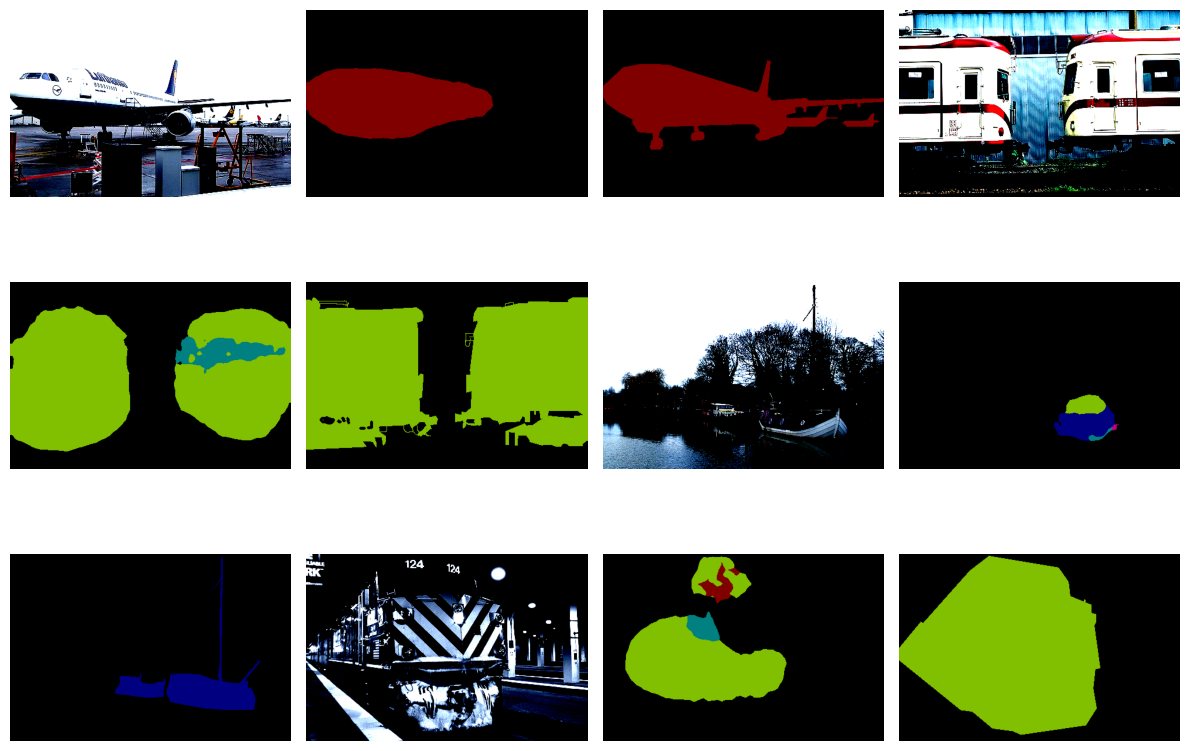

In [12]:
VOC_MEAN = torch.tensor([0.485, 0.456, 0.406])
VOC_STD = torch.tensor([0.229, 0.224, 0.225])
VOC_COLORMAP = torch.tensor([
    [0, 0, 0],        # background
    [128, 0, 0],      # aeroplane
    [0, 128, 0],      # bicycle
    [128, 128, 0],    # bird
    [0, 0, 128],      # boat
    [128, 0, 128],    # bottle
    [0, 128, 128],    # bus
    [128, 128, 128],  # car
    [64, 0, 0],       # cat
    [192, 0, 0],      # cow
    [64, 128, 0],     # diningtable
    [192, 128, 0],    # dog
    [64, 0, 128],     # horse
    [192, 0, 128],    # motorbike
    [64, 128, 128],   # person
    [192, 128, 128],  # potted plant
    [0, 64, 0],       # sheep
    [128, 64, 0],     # sofa
    [0, 192, 0],      # train
    [128, 192, 0],    # tvmonitor
])

# 加载最优权重
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weight_path = "fcn8s_best.pth"
model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
model.to(DEVICE)

visualize_voc_prediction(net=model, test_dataset=test_iter.dataset, device=DEVICE, num_sample=4)